<a href="https://colab.research.google.com/github/mustapharitani13-cpu/smart-news-analyzer/blob/main/exerice2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_json('/content/news_dataset (1).json')

In [ ]:
df.head()

,text,category
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS
3,This Richard Sherman Interception Literally Sh...,SPORTS
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7500 entries, 0 to 7499
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      7500 non-null   object
 1   category  7500 non-null   object
dtypes: object(2)
memory usage: 175.8+ KB


In [ ]:
df.describe()

,text,category
count,7500,7500
unique,7497,3
top,9 Terrifying American Murder Houses,CRIME
freq,2,2500


In [ ]:
df.isnull().sum()

,0
text,0
category,0


In [ ]:
df.category.value_counts()

,count
category,
CRIME,2500
SPORTS,2500
BUSINESS,2500


In [ ]:
!python -m spacy download en_core_web_lg
import spacy
nlp=spacy.load('en_core_web_lg')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
df['num_category']=df['category'].map({'CRIME':0, 'SPORTS':1, 'BUSINESS':2})

In [ ]:
df.head()

,text,category,num_category
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,0
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,0
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,1
3,This Richard Sherman Interception Literally Sh...,SPORTS,1
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,2


In [ ]:
def preprocess(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return ' '.join(filtered_tokens)


In [ ]:
df['preprocessed_text']=df['text'].apply(lambda x: preprocess(x))

In [ ]:
df.head()

,text,category,num_category,preprocessed_text
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,0,Larry Nassar blame Victims say victimize newly...
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,0,woman Beats Cancer dies fall Horse
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,1,Vegas Taxpayers spend record $ 750 million New...
3,This Richard Sherman Interception Literally Sh...,SPORTS,1,Richard Sherman Interception literally shake W...
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,2,7 thing totally kill weed legalization Buzz


In [ ]:
df['vector'] = df['preprocessed_text'].apply(lambda text: nlp(text).vector)

In [ ]:
df.head()

,text,category,num_category,preprocessed_text,vector
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,0,Larry Nassar blame Victims say victimize newly...,"[-0.3472573, 0.021758832, -0.2137525, -0.01718..."
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,0,woman Beats Cancer dies fall Horse,"[-0.16791849, 0.43708333, 0.035527337, 0.01661..."
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,1,Vegas Taxpayers spend record $ 750 million New...,"[0.053351898, 0.08053064, -0.05101806, -0.1991..."
3,This Richard Sherman Interception Literally Sh...,SPORTS,1,Richard Sherman Interception literally shake W...,"[-0.038867258, 0.28459162, 0.071352966, -0.045..."
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,2,7 thing totally kill weed legalization Buzz,"[-0.20180944, 0.11867001, 0.0036708585, -0.189..."


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test=train_test_split(
    df.vector.values,
    df.num_category,
    test_size=0.2,
    random_state=2025,
    stratify=df.num_category
)

In [ ]:
import numpy as np
X_train_2d=np.stack(x_train)
X_test_2d=np.stack(x_test)

In [ ]:
X_train_2d.shape

(6000, 300)

In [ ]:
X_test_2d.shape

(1500, 300)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf=RandomForestClassifier(n_estimators=150,criterion='gini')
clf.fit(X_train_2d, y_train)

RandomForestClassifier(n_estimators=150)

In [ ]:
y_pred=clf.predict(X_test_2d)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       500
           1       0.90      0.90      0.90       500
           2       0.91      0.90      0.90       500

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaled_train=scaler.fit_transform(X_train_2d)
scaled_test=scaler.transform(X_test_2d)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
clf_nb=MultinomialNB()
clf_nb.fit(scaled_train, y_train)

MultinomialNB()

In [ ]:
y_pred=clf_nb.predict(scaled_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90       500
           1       0.90      0.85      0.87       500
           2       0.87      0.90      0.88       500

    accuracy                           0.88      1500
   macro avg       0.88      0.88      0.88      1500
weighted avg       0.88      0.88      0.88      1500



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_clf=KNeighborsClassifier(  n_neighbors=5,
    metric='euclidean',
    weights='uniform')

In [ ]:
knn_clf.fit(X_train_2d, y_train)

KNeighborsClassifier(metric='euclidean')

In [ ]:
y_pred=knn_clf.predict(X_test_2d)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       500
           1       0.92      0.87      0.89       500
           2       0.92      0.88      0.90       500

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [ ]:
gbc.fit(X_train_2d, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred=gbc.predict(X_test_2d)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       500
           1       0.90      0.90      0.90       500
           2       0.91      0.91      0.91       500

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500



Text(95.72222222222221, 0.5, 'Truth')

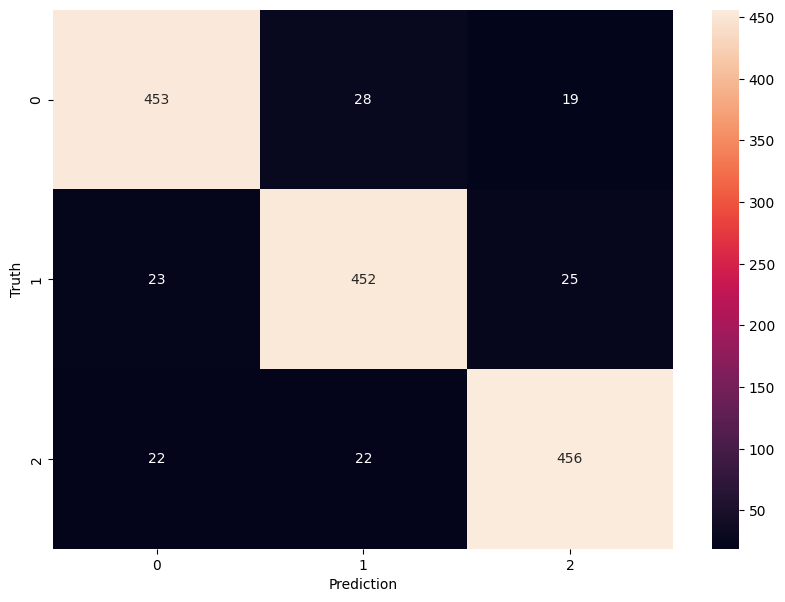

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm


from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')

In [ ]:
df['text_vector']=df['text'].apply(lambda x: nlp(x).vector)

In [ ]:
df.head()

,text,category,num_category,text_vector
0,"Larry Nassar Blames His Victims, Says He 'Was ...",CRIME,0,"[-0.12600185, 0.2670082, -0.16627134, -0.06346..."
1,"Woman Beats Cancer, Dies Falling From Horse",CRIME,0,"[-0.15009212, 0.39993936, -0.030083999, 0.0827..."
2,Vegas Taxpayers Could Spend A Record $750 Mill...,SPORTS,1,"[0.0686294, 0.079817496, -0.10145511, -0.09158..."
3,This Richard Sherman Interception Literally Sh...,SPORTS,1,"[-0.05209184, 0.2640776, 0.024623524, -0.05012..."
4,7 Things That Could Totally Kill Weed Legaliza...,BUSINESS,2,"[-0.1287915, 0.17678502, -0.064180195, -0.1208..."


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(
    df.text_vector.values,
    df.num_category,
    test_size=0.2,
    random_state=2025
)

In [ ]:
import numpy as np
x_train_2d=np.stack(x_train)
x_test_2d=np.stack(x_test)

In [ ]:
# the solution can help you is to do scaling min-max
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaled_train_embad=scaler.fit_transform(x_train_2d)
scaled_test_embad=scaler.transform(x_test_2d) # we do it also for test but only transform NOT with fit.

from sklearn.naive_bayes import MultinomialNB
clf=MultinomialNB()
clf.fit(scaled_train_embad, y_train)

MultinomialNB()

In [ ]:
y_pred=clf.predict(scaled_test_embad)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       498
           1       0.88      0.81      0.85       480
           2       0.80      0.89      0.84       522

    accuracy                           0.86      1500
   macro avg       0.87      0.86      0.86      1500
weighted avg       0.87      0.86      0.86      1500



In [ ]:
# knn algorithm
from sklearn.neighbors import KNeighborsClassifier
knn_clf=KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_clf.fit(scaled_train_embad, y_train)

KNeighborsClassifier(metric='euclidean')

In [ ]:
y_pred=knn_clf.predict(scaled_test_embad)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       498
           1       0.91      0.84      0.88       480
           2       0.89      0.90      0.90       522

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500

